## Data Exploration

Structure of the JSON File is explained here:
https://cache.industry.siemens.com/dl/files/818/109772818/att_1002066/v1/AMWT_Capture_OP_man_en-US.pdf

### Import Files
Paths to raw data in "Rohdaten/'TRIAL_NUMBER'/\*.json".

In [1]:
def create_file_paths(base_path, trial_prefix, unique_ids):
    file_paths = [
        f"{base_path}/{trial_prefix}/RS_Werkzeugverschleis_{uid}.json"
        for uid in unique_ids
    ]
    return file_paths

unique_ids = []

# Trial 1_1
unique_ids.append([
    "9aa269e9-3cee-43cb-9ea7-79b06305168a_20220610-065456",
    "9aa269e9-3cee-43cb-9ea7-79b06305168a_20220610-065932",
    "c74efe1f-def0-4b7d-bdf3-352baa881f78_20220610-070858",
    "c74efe1f-def0-4b7d-bdf3-352baa881f78_20220610-071332",
])

# Trial 1_2
unique_ids.append([
    "00db9c52-55d4-4872-a5c5-a1c304fd8fd0_20220610-073518",
    "00db9c52-55d4-4872-a5c5-a1c304fd8fd0_20220610-073953",
    "5a92de8d-d44b-4fd8-900c-e8b815909d9b_20220610-075006",
    "5a92de8d-d44b-4fd8-900c-e8b815909d9b_20220610-075446",
])

# Trial 2_1
unique_ids.append([
    "36bbd7dc-c529-4412-a1b5-de6f9c3ea9b0_20220610-114003",
    "36bbd7dc-c529-4412-a1b5-de6f9c3ea9b0_20220610-114440",
    "65db4367-dbfb-4ecd-94d3-00c017e5e0bc_20220610-112840",
    "65db4367-dbfb-4ecd-94d3-00c017e5e0bc_20220610-113314",
    "e27023d3-b876-415e-9d17-eb4415cf0f4f_20220610-110131",
    "e27023d3-b876-415e-9d17-eb4415cf0f4f_20220610-110604"
])

# Trial 3_1
unique_ids.append([
    "6336c20a-64bf-4ca1-a73e-455108fa6e54_20220610-092141",
    "dc8b0de3-62ee-40f5-b2ee-e95d729d610b_20220610-091025",
    "dc8b0de3-62ee-40f5-b2ee-e95d729d610b_20220610-091501"
])

# Trial 3_3
unique_ids.append([
    "b3af8aee-9ac2-4399-9b9a-92fc195db90b_20220610-104606",
    "d0ded7e9-5d66-40bf-be7b-441770448c95_20220610-103428",
    "d0ded7e9-5d66-40bf-be7b-441770448c95_20220610-103906"
])

raw_data_path = "Rohdaten/"

In [2]:
trial_numbers = ["1_1","1_2","2_1","3_1","3_3"]
trial_runs = len(trial_numbers)

paths = [
    create_file_paths(raw_data_path, trial_numbers[trial], unique_ids[trial])
    for trial in range(trial_runs)
]

In [3]:
import json

def load_json_files(file_paths):
    data = []
    for path in file_paths:
        with open(path, "r") as file:
            data.append(json.load(file))
    return data

Imports json files into an array.

In [4]:
json_data = [
    load_json_files(path)
    for path in paths
]

### Format
Creates a pandas DataFrame from JSON files. data_frame is an array holding the files for each trial run. Each data_frame entry then holds the JSON data from each of the trial runs' files. 

In [5]:
import pandas as pd

data_frame = []
for json in json_data:
    data_frame.append(pd.json_normalize(json))
data_frame[0]

,Payload,Header.Version.outputFileFormatVersion,Header.Version.RecorderVersion,Header.Format,Header.Description,Header.MachineInfo.MachineName,Header.MachineInfo.CFCard,Header.JobDescription,Header.SignalListHFData,Header.SignalListLFData,Header.TimeStamp,Header.CycleTimeMs,Header.Initial.Time,Header.Initial.HFProbeCounter,Footer.ErrorMessages,Footer.FilePathChain.Previous,Footer.FilePathChain.Actual,Footer.FilePathChain.Next,Footer.FilePathChain.Index,Footer.FilePathChain.StreamIndex
0,"[{'HFData': [[1596582, -0.395681, -0.177939, 5...",0.8,2.5.1.0.4,DEFAULT,None,sinumerik_adapter_840Dsl,000060141185B1000000,"[""TriggersOn"":, ""TriggersOff"":]","[{'Name': 'Cycle', 'Type': 'INTEGER', 'Axis': ...",[],2022-06-10T06:54:56.765537Z,2,2022-06-10T08:27:43.012Z,1596582,[],None,RS_Werkzeugverschleis_9aa269e9-3cee-43cb-9ea7-...,RS_Werkzeugverschleis_9aa269e9-3cee-43cb-9ea7-...,2,None
1,"[{'HFData': [[1734669, -0.496357, -0.700051, 5...",0.8,2.5.1.0.4,DEFAULT,None,sinumerik_adapter_840Dsl,000060141185B1000000,"[""TriggersOn"":, ""TriggersOff"":]","[{'Name': 'Cycle', 'Type': 'INTEGER', 'Axis': ...",[],2022-06-10T06:59:32.784262Z,2,2022-06-10T08:32:18.996Z,1734668,[],RS_Werkzeugverschleis_9aa269e9-3cee-43cb-9ea7-...,RS_Werkzeugverschleis_9aa269e9-3cee-43cb-9ea7-...,None,3,None
2,"[{'HFData': [[2016965, -0.348855, 0.079604, 5....",0.8,2.5.1.0.4,DEFAULT,None,sinumerik_adapter_840Dsl,000060141185B1000000,"[""TriggersOn"":, ""TriggersOff"":]","[{'Name': 'Cycle', 'Type': 'INTEGER', 'Axis': ...",[],2022-06-10T07:08:59.097086Z,2,2022-06-10T08:41:43.813Z,2016965,[],None,RS_Werkzeugverschleis_c74efe1f-def0-4b7d-bdf3-...,RS_Werkzeugverschleis_c74efe1f-def0-4b7d-bdf3-...,4,None
3,"[{'HFData': [[2154423, -0.592351, -0.777314, 5...",0.8,2.5.1.0.4,DEFAULT,None,sinumerik_adapter_840Dsl,000060141185B1000000,"[""TriggersOn"":, ""TriggersOff"":]","[{'Name': 'Cycle', 'Type': 'INTEGER', 'Axis': ...",[],2022-06-10T07:13:32.331817Z,2,2022-06-10T08:46:18.640Z,2154422,[],RS_Werkzeugverschleis_c74efe1f-def0-4b7d-bdf3-...,RS_Werkzeugverschleis_c74efe1f-def0-4b7d-bdf3-...,None,5,None


In [6]:
data_frame[0]["Header.TimeStamp"][0]

'2022-06-10T06:54:56.765537Z'

In [7]:
data_frame[0]["Header.MachineInfo.MachineName"][0]

'sinumerik_adapter_840Dsl'

The **"Header.SignalListHFData"** column holds the name for the attributes of **"HFData"** in the JSON payload.

In [8]:
attributes = pd.DataFrame(data_frame[0]["Header.SignalListHFData"][0])
attributes

,Name,Type,Axis,Address
0,Cycle,INTEGER,CYCLE,CYCLE
1,Torque,DOUBLE,X1,TORQUE|1
2,Torque,DOUBLE,Y1,TORQUE|2
3,Torque,DOUBLE,Z1,TORQUE|3
4,Torque,DOUBLE,C1,TORQUE|4
...,...,...,...,...
87,ActualAxisPosition,DOUBLE,Y1,ENC_POS|2
88,ActualAxisPosition,DOUBLE,Z1,ENC_POS|3
89,ActualAxisPosition,DOUBLE,C1,ENC_POS|4
90,ActualAxisPosition,DOUBLE,B1,ENC_POS|5


**payloads** is an array holding the payload of the JSON data. It contains the time series data of the trial runs.
- Its first index references the trial run. 
- The second index references the file in the trial run
- The third index references data points of the trial run (?)(=2030 in trial 1)

Each data point contains a signal. There are 3 types of signals: "HFData", "HFCallEvent", "HFBlockEvent".

In [9]:
payloads = [
    data_frame[i]["Payload"] 
    for i in range(trial_runs)
]

If the signal is "HFData" it contains approximately 20-100 data points again. They can be accessed referencing the "HFData" column.

In [10]:
hf_data = pd.DataFrame(payloads[0][0][2003]["HFData"], columns=attributes["Address"])
hf_data

Address,CYCLE,TORQUE|1,TORQUE|2,TORQUE|3,TORQUE|4,TORQUE|5,TORQUE|6,CTRL_DIFF2|1,CTRL_DIFF2|2,CTRL_DIFF2|3,...,LOAD|3,LOAD|4,LOAD|5,LOAD|6,ENC_POS|1,ENC_POS|2,ENC_POS|3,ENC_POS|4,ENC_POS|5,ENC_POS|6
0,1732640,1.285378,-1.219822,6.003115,None,None,-2.737826,0.000816,0.022018,0.000778,...,24.389648,None,None,6.097412,-277.565696,-185.193016,-355.78177,None,None,5.168376e+06
1,1732641,1.245576,-1.158948,6.040576,None,None,-2.737826,0.000606,0.022202,0.000458,...,24.511719,None,None,6.121826,-277.565486,-185.184866,-355.78145,None,None,5.168414e+06
2,1732642,1.308792,-1.081685,5.989067,None,None,-2.737826,-0.000564,0.021744,0.000298,...,24.511719,None,None,6.121826,-277.564316,-185.176075,-355.78129,None,None,5.168452e+06
3,1732643,1.247918,-1.032517,6.031211,None,None,-2.731165,-0.000944,0.021367,0.000018,...,24.481201,None,None,6.109619,-277.563936,-185.167365,-355.78101,None,None,5.168491e+06
4,1732644,1.294744,-0.920134,6.007798,None,None,-2.724503,-0.001194,0.020991,-0.000562,...,24.481201,None,None,6.109619,-277.563686,-185.158655,-355.78043,None,None,5.168529e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,1732737,1.243235,-1.004421,6.017163,None,None,-2.731165,-0.000824,0.021523,-0.000192,...,24.432373,None,None,6.103516,-277.564056,-184.384187,-355.78080,None,None,5.172100e+06
98,1732738,1.273672,-0.950571,5.984385,None,None,-2.724503,-0.001344,0.021106,-0.000112,...,24.432373,None,None,6.103516,-277.563536,-184.375436,-355.78088,None,None,5.172139e+06
99,1732739,1.203433,-0.931841,6.012481,None,None,-2.717842,-0.001044,0.021369,-0.000042,...,24.395752,None,None,6.072998,-277.563836,-184.367366,-355.78095,None,None,5.172177e+06
100,1732740,1.313474,-1.114463,6.000774,None,None,-2.717842,0.000116,0.021422,-0.000482,...,24.395752,None,None,6.072998,-277.564996,-184.359086,-355.78051,None,None,5.172216e+06


### Visualizing Data

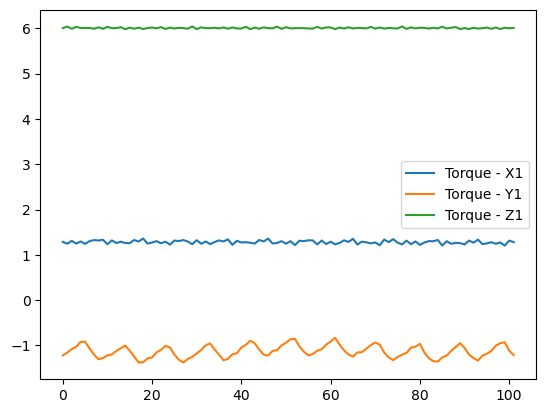

In [11]:
import matplotlib.pyplot as plt

hf_torque_data = [
    hf_data["TORQUE|1"], 
    hf_data["TORQUE|2"], 
    hf_data["TORQUE|3"],
]

labels = ["Torque - X1", "Torque - Y1", "Torque - Z1"]
for plot in range(len(hf_torque_data)):
    plt.plot(hf_torque_data[plot], label=labels[plot])
plt.legend()
plt.show()


In [12]:
def get_signal_type(signal):
    return list(signal.keys())[0]

In [34]:
def concat_trial_records(payload, test=False):
    concat_trials = []

    for t, trial in enumerate(payload):
        hf_data_frames = [
            pd.DataFrame(signal["HFData"], columns=attributes["Address"])
            for file in trial
            for signal in file
            if get_signal_type(signal) == "HFData"
        ]
        
        if hf_data_frames:
            concat_trials.append(
                pd.concat(
                    hf_data_frames,
                    axis=0,
                    ignore_index=True,
                    copy=False
                )
            )
        else:
            concat_trials.append(pd.DataFrame())

        if test:
            break

    return concat_trials


In [35]:
trials_records = concat_trial_records(payloads)
trials_records[0]

Address,CYCLE,TORQUE|1,TORQUE|2,TORQUE|3,TORQUE|4,TORQUE|5,TORQUE|6,CTRL_DIFF2|1,CTRL_DIFF2|2,CTRL_DIFF2|3,...,LOAD|3,LOAD|4,LOAD|5,LOAD|6,ENC_POS|1,ENC_POS|2,ENC_POS|3,ENC_POS|4,ENC_POS|5,ENC_POS|6
0,1596582,-0.395681,-0.177939,5.832200,None,None,0.000000,-0.000020,0.000030,0.000015,...,23.651123,None,None,0.000000,-599.999980,-548.200030,-8.400014,None,None,90.000620
1,1596583,-0.381633,-0.187305,5.822835,None,None,0.000000,-0.000030,0.000030,0.000005,...,23.657227,None,None,0.000000,-599.999970,-548.200030,-8.400004,None,None,90.000620
2,1596584,-0.398022,-0.187305,5.832200,None,None,0.000000,-0.000020,0.000040,0.000005,...,23.657227,None,None,0.000000,-599.999980,-548.200040,-8.400004,None,None,90.001307
3,1596585,-0.388657,-0.187305,5.825176,None,None,0.000000,-0.000020,0.000040,0.000005,...,23.632812,None,None,0.000000,-599.999980,-548.200040,-8.400004,None,None,90.000620
4,1596586,-0.386316,-0.180281,5.832200,None,None,0.000000,-0.000020,0.000030,0.000005,...,23.632812,None,None,0.000000,-599.999980,-548.200030,-8.400004,None,None,90.000620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469492,2239385,-0.472944,-0.784338,6.263001,None,None,-0.006661,0.000008,-0.000018,-0.000009,...,25.408936,None,None,0.012207,-227.659686,-194.485317,-373.689787,None,None,156.477518
469493,2239386,-0.456555,-0.784338,6.260659,None,None,-0.006661,-0.000002,-0.000018,0.000001,...,25.408936,None,None,0.012207,-227.659676,-194.485317,-373.689797,None,None,156.477518
469494,2239387,-0.458896,-0.772632,6.260659,None,None,-0.006661,0.000008,-0.000018,-0.000009,...,25.402832,None,None,0.012207,-227.659686,-194.485317,-373.689787,None,None,156.477518
469495,2239388,-0.458896,-0.767949,6.260659,None,None,-0.006661,0.000008,-0.000008,0.000001,...,25.402832,None,None,0.012207,-227.659686,-194.485327,-373.689797,None,None,156.477518


In [39]:
def save_to_csv(csv_path, trial_records):
    for t, trial_record in enumerate(trial_records):
        f = open(f"{csv_path}/trial_{t}.csv", "w")
        f.write(trial_record.to_csv())

In [40]:
csv_path = "csv"
save_to_csv(csv_path, trials_records)

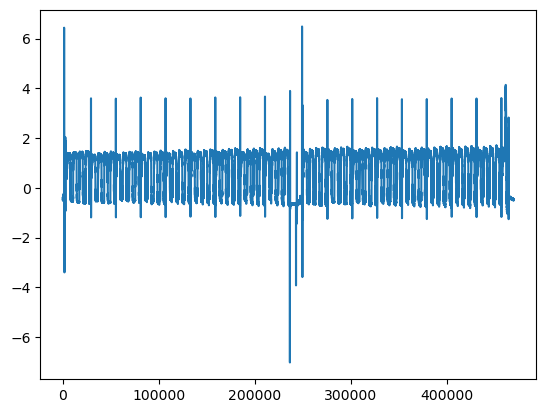

In [42]:
plt.plot(trials_records[0]["TORQUE|1"])
plt.show()